#ML FINAL EXAM

### Email:sheikhmohammedsayedali@gmail.com

Task: Copy this notebook on your drive and answer in that copy

Choose a dataset of your choice from kaggle or UCI

Some suggestions:https://www.kaggle.com/datasets/ahmettezcantekin/beginner-datasets

You may choose a dataset of your choice too

In this exam:
1. Provide code and explaination(in text cell) whenever needed and you must show the outputs
2. Before submitting run all cells and make sure the outputs are visible


## 0. Dataset overview

Why you choose this dataset and what did you observe from the dataset description



  

## Answer:
I have selected the Diabetes dataset because it is easy to understand and it represents a real medical problem. The goal is to predict whether a person has diabetes or not using patient health information.



# 1. Dataset description (15 marks)


### Dataset Description
1. How many features?
2. Classification or regression problem? Why do you think so?
3. How many data points?
4. Is there any null values?
5. What kind of features are in your dataset? (Quantitative / Categorical)
6. Do you need to encode the categorical variables, why or why not?
7. Correlation of all the features, What do you understand after the correlation test?
8. Perform exploratory data analysis to extract some important relationships from your data.


Provide necessary codes and explanation

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.impute import SimpleImputer

df=pd.read_csv('diabetes.csv')
df.sample(100)


,Number of times pregnant,Plasma glucose concentration a 2 hours in an oral glucose tolerance test,Diastolic blood pressure (mm Hg),Triceps skin fold thickness (mm),2-Hour serum insulin (mu U/ml),Body mass index (weight in kg/(height in m)^2),Diabetes pedigree function,Age (years),Class variable
614,11,138,74,26,144,36.1,0.557,50,1
121,6,111,64,39,0,34.2,0.260,24,0
464,10,115,98,0,0,24.0,1.022,34,0
131,9,122,56,0,0,33.3,1.114,33,1
260,3,191,68,15,130,30.9,0.299,34,0
...,...,...,...,...,...,...,...,...,...
233,4,122,68,0,0,35.0,0.394,29,0
162,0,114,80,34,285,44.2,0.167,27,0
545,8,186,90,35,225,34.5,0.423,37,1
574,1,143,86,30,330,30.1,0.892,23,0


In [ ]:
print(df.shape)
print()
print(df.dtypes)
print()

print(df.isnull().sum())




(768, 9)

Number of times pregnant                                                      int64
Plasma glucose concentration a 2 hours in an oral glucose tolerance test      int64
Diastolic blood pressure (mm Hg)                                              int64
Triceps skin fold thickness (mm)                                              int64
2-Hour serum insulin (mu U/ml)                                                int64
Body mass index (weight in kg/(height in m)^2)                              float64
Diabetes pedigree function                                                  float64
Age (years)                                                                   int64
Class variable                                                                int64
dtype: object

Number of times pregnant                                                    0
Plasma glucose concentration a 2 hours in an oral glucose tolerance test    0
Diastolic blood pressure (mm Hg)                               

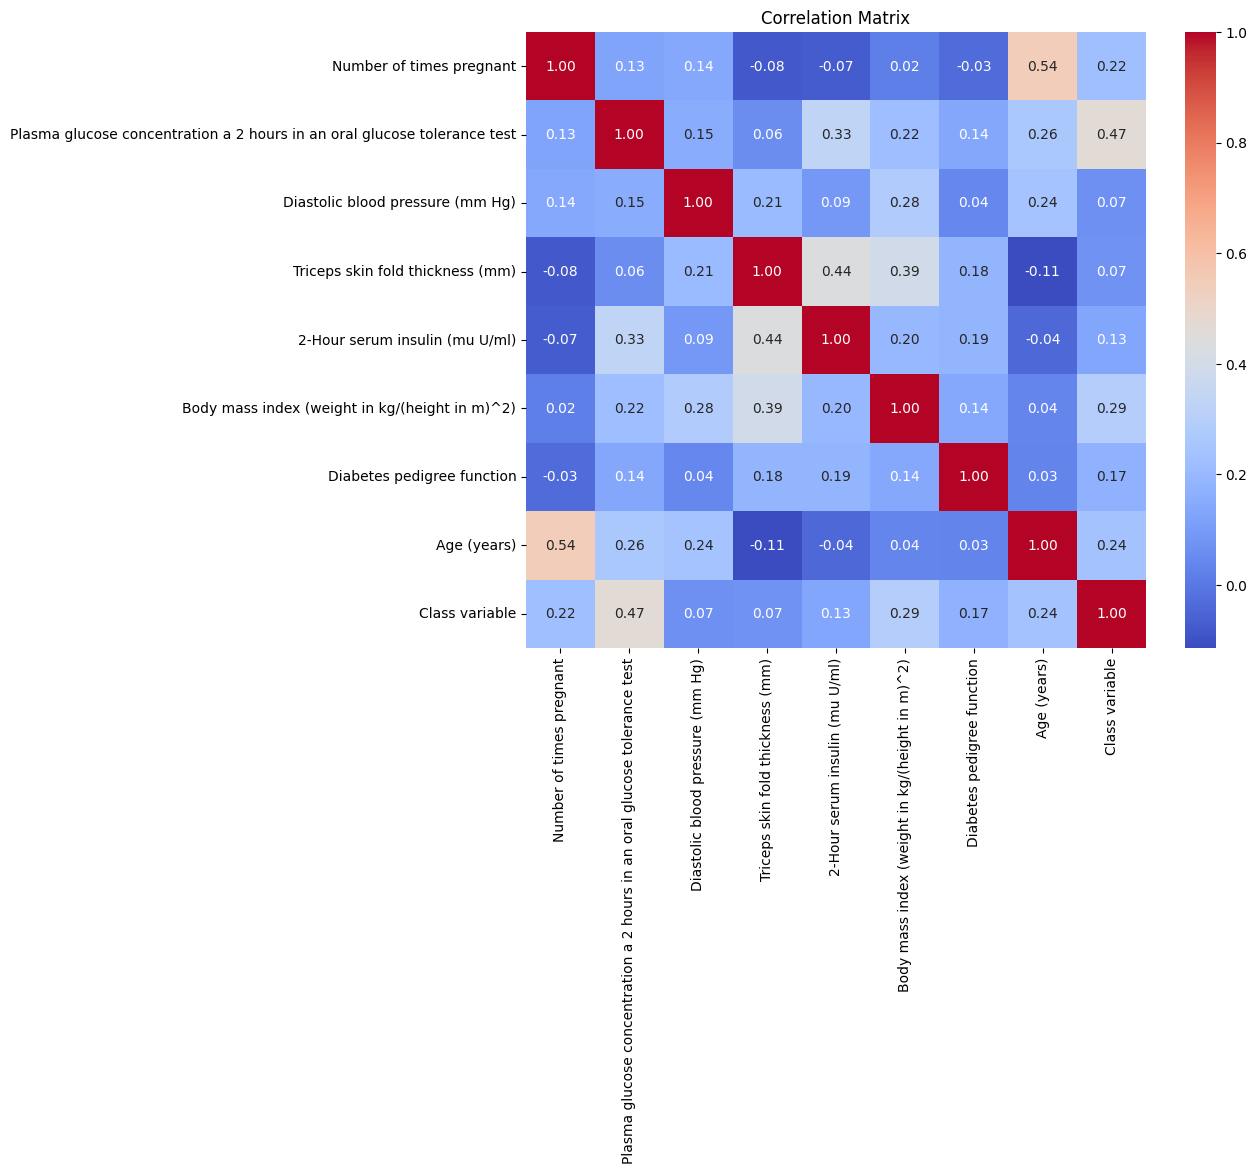

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm",
            fmt=".2f")

plt.title("Correlation Matrix")
plt.show()

##Answer:
1...The dataset contains 8 input features and 1 target variable(Class variable)

2..It is a binary classification problem..because target variable has two classes

3.. datapoints  768

4..There are no null values, but some features contain 0 values, which may represent missing or invalid data.

5...numerical data here

6..No,because all features are numerical and there are no categorical variables.

7..The correlation analysis shows that Plasma Glucose has the highest positive correlation (0.47) with the Class Variable, followed by BMI (0.29), Age (0.24), and Pregnancies (0.22). Most other features have weak correlations with the target. Also, no pair of features has a very high correlation (above 0.8), indicating that severe multicollinearity is not present in the dataset.

8...High glucose and BMI increase the chance of diabetes.

#2. Dataset pre-processing (15 marks)

1. Provide code
2. Discuss the pre processing steps you applied and why?


## Answer:

First of all , i checked the null values to identifing any missing values in the dataset..then checked  the duplicate values .After that i handled invalid zero values in medical features (Glucose, Blood Pressure, Skin Thickness, Insulin, and BMI). Since a value of 0 is not realistic for these measurements, they were treated as missing values....Here no encoding was applied because all features in the dataset are numerical


   

In [ ]:
print(df.duplicated().sum())


print(df.isnull().sum())


print(df.duplicated().sum())


df = df.drop_duplicates()

age_median = df["Age (years)"].median()

print(age_median)

df["Age (years)"] = df["Age (years)"].fillna(age_median)


df["Age (years)"]
df.sample(12)

cols = [
    "Plasma glucose concentration a 2 hours in an oral glucose tolerance test",
    "Diastolic blood pressure (mm Hg)",
    "Triceps skin fold thickness (mm)",
    "2-Hour serum insulin (mu U/ml)",
    "Body mass index (weight in kg/(height in m)^2)"
]

df[cols] = df[cols].replace(0, np.nan)

imputer = SimpleImputer(strategy="median")

df[cols] = imputer.fit_transform(df[cols])

0
Number of times pregnant                                                    0
Plasma glucose concentration a 2 hours in an oral glucose tolerance test    0
Diastolic blood pressure (mm Hg)                                            0
Triceps skin fold thickness (mm)                                            0
2-Hour serum insulin (mu U/ml)                                              0
Body mass index (weight in kg/(height in m)^2)                              0
Diabetes pedigree function                                                  0
Age (years)                                                                 0
Class variable                                                              0
dtype: int64
0
29.0


#3.Feature selection and Dataset splitting (10 marks)

1. Which features you wanna keep ? Justify and drop and rest or apply any other feature engineering step
2. Perform Train test split

## Answer:

I did not drop any features because all of them are medically relevant for predicting diabetes, and there was no strong evidence that any feature was irrelevant.

The dataset was divided into 80% training data and 20% testing data using train_test_split(). The random_state=42 parameter was used to ensure reproducible results, and stratify=y was used to preserve the class distribution in both the training and testing sets.

In [ ]:
X=df.drop('Class variable',axis=1)
y=df['Class variable']
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)


#4.  Pipeline Creation (Supervised) (10 marks)

Select 2 models of your choice and build 2 pipelines for them

## Answer:

In [ ]:
# logistic regression + decision tree

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

pipline_1=Pipeline([
    ('scaler',StandardScaler()),
    ('model',LogisticRegression(max_iter=500))
])

pipline_2=Pipeline([
    ('scaler',StandardScaler()),
    ('model',DecisionTreeClassifier(random_state=42))
])


In [ ]:
pipline_1

Pipeline(steps=[('scaler', StandardScaler()),
                ('model', LogisticRegression(max_iter=500))])

In [ ]:
pipline_2

Pipeline(steps=[('scaler', StandardScaler()),
                ('model', DecisionTreeClassifier(random_state=42))])

# 5. Model Training (5 marks)

Train those 2 models



## Answer:

In [ ]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score

# pipline_1
pipline_1.fit(X_train,y_train)


# pipline_2
pipline_2.fit(X_train,y_train)








Pipeline(steps=[('scaler', StandardScaler()),
                ('model', DecisionTreeClassifier(random_state=42))])

#6. Model selection/Comparison analysis (15 marks)
* Bar chart showcasing prediction accuracy of all models (for classification)
* Precision, recall comparison of each model. (for classification)
* Confusion Matrix (for classification)
* R2 score and Loss  (for regression)

Compare the results of all models based on all of the above described metrics. Why do you think this model performed better than the other one for this dataset?

# Answer:

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score


# pip1

y_pred_1=pipline_1.predict(X_test)
accuracy_1=accuracy_score(y_test,y_pred_1)
precision_1=precision_score(y_test,y_pred_1)
recall_1=recall_score(y_test,y_pred_1)

#pip2

y_pred_2=pipline_2.predict(X_test)
accuracy_2=accuracy_score(y_test,y_pred_2)
precision_2=precision_score(y_test,y_pred_2)
recall_2=recall_score(y_test,y_pred_2)

In [ ]:
print("Logistic Regression")
print("Accuracy :", accuracy_1)
print("Precision :", precision_1)
print("Recall :", recall_1)

print()

print("Decision Tree")
print("Accuracy :", accuracy_2)
print("Precision :", precision_2)
print("Recall :", recall_2)

Logistic Regression
Accuracy : 0.7077922077922078
Precision : 0.6
Recall : 0.5

Decision Tree
Accuracy : 0.6818181818181818
Precision : 0.5531914893617021
Recall : 0.48148148148148145


In [ ]:
from sklearn.metrics import confusion_matrix
conf_met_1=confusion_matrix(y_test,y_pred_1)
conf_met_2=confusion_matrix(y_test,y_pred_2)

print(conf_met_1)
print(conf_met_2)

[[82 18]
 [27 27]]
[[79 21]
 [28 26]]


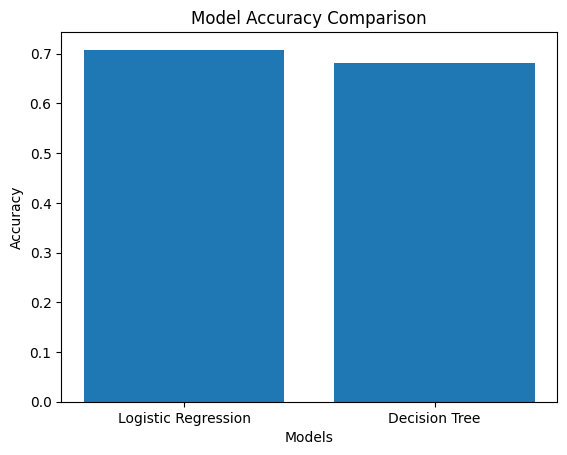

In [ ]:
import matplotlib.pyplot as plt

models = ["Logistic Regression", "Decision Tree"]
accuracy = [accuracy_1, accuracy_2]

plt.bar(models, accuracy)
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.show()

In [ ]:
#Option 1: Logistic Regression + KNN

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

pipeline_1 = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=500))
])

pipeline_2 = Pipeline([
    ("scaler", StandardScaler()),
    ("model", KNeighborsClassifier(n_neighbors=5))
])

pipeline_1.fit(X_train, y_train)
pipeline_2.fit(X_train, y_train)

y_pred_1 = pipeline_1.predict(X_test)
y_pred_2 = pipeline_2.predict(X_test)

accuracy_1 = accuracy_score(y_test, y_pred_1)
accuracy_2 = accuracy_score(y_test, y_pred_2)

precision_1 = precision_score(y_test, y_pred_1)
precision_2 = precision_score(y_test, y_pred_2)

recall_1 = recall_score(y_test, y_pred_1)
recall_2 = recall_score(y_test, y_pred_2)

print("Logistic Regression")
print("Accuracy:", accuracy_1)
print("Precision:", precision_1)
print("Recall:", recall_1)



print("\nKNN")
print("Accuracy:", accuracy_2)
print("Precision:", precision_2)
print("Recall:", recall_2)

Logistic Regression
Accuracy: 0.7077922077922078
Precision: 0.6
Recall: 0.5

KNN
Accuracy: 0.7532467532467533
Precision: 0.66
Recall: 0.6111111111111112


In [ ]:
#  Option 2: Logistic Regression + Random Forest
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

pipeline_1 = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=500))
])

pipeline_2 = Pipeline([
    ("model", RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ))
])

pipeline_1.fit(X_train, y_train)
pipeline_2.fit(X_train, y_train)

y_pred_1 = pipeline_1.predict(X_test)
y_pred_2 = pipeline_2.predict(X_test)

accuracy_1 = accuracy_score(y_test, y_pred_1)
accuracy_2 = accuracy_score(y_test, y_pred_2)

precision_1 = precision_score(y_test, y_pred_1)
precision_2 = precision_score(y_test, y_pred_2)

recall_1 = recall_score(y_test, y_pred_1)
recall_2 = recall_score(y_test, y_pred_2)

print("Logistic Regression")
print("Accuracy:", accuracy_1)
print("Precision:", precision_1)
print("Recall:", recall_1)



print("\nRandom Forest")
print("Accuracy:", accuracy_2)
print("Precision:", precision_2)
print("Recall:", recall_2)




Logistic Regression
Accuracy: 0.7077922077922078
Precision: 0.6
Recall: 0.5

Random Forest
Accuracy: 0.7792207792207793
Precision: 0.7272727272727273
Recall: 0.5925925925925926


In [ ]:
# Option 3: SVM + Random Forest

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

pipeline_1 = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC())
])

pipeline_2 = Pipeline([
    ("model", RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ))
])

pipeline_1.fit(X_train, y_train)
pipeline_2.fit(X_train, y_train)

y_pred_1 = pipeline_1.predict(X_test)
y_pred_2 = pipeline_2.predict(X_test)
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

accuracy_1 = accuracy_score(y_test, y_pred_1)
accuracy_2 = accuracy_score(y_test, y_pred_2)

precision_1 = precision_score(y_test, y_pred_1)
precision_2 = precision_score(y_test, y_pred_2)

recall_1 = recall_score(y_test, y_pred_1)
recall_2 = recall_score(y_test, y_pred_2)

print("SVM")
print("Accuracy:", accuracy_1)
print("Precision:", precision_1)
print("Recall:", recall_1)

print("\nRandom Forest")
print("Accuracy:", accuracy_2)
print("Precision:", precision_2)
print("Recall:", recall_2)

SVM
Accuracy: 0.7402597402597403
Precision: 0.6521739130434783
Recall: 0.5555555555555556

Random Forest
Accuracy: 0.7792207792207793
Precision: 0.7272727272727273
Recall: 0.5925925925925926


In [ ]:
# just knn_with_gridsearch

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

# Pipeline
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", KNeighborsClassifier())
])

# Hyperparameters

grid_param = [
    {
        "model__n_neighbors": [3, 5, 7, 9, 11],
        "model__weights": ["uniform", "distance"],
        "model__metric": ["euclidean", "manhattan"]
    }
]

# GridSearchCV
grid = GridSearchCV(
    estimator=pipeline,
    param_grid=grid_param,
    cv=5,
    scoring="accuracy"
)

# Training
grid.fit(X_train, y_train)

# Best Parameters
print("Best Parameters:", grid.best_params_)
print("Best Cross Validation Accuracy:", grid.best_score_)

# Prediction
y_pred = grid.predict(X_test)

# Evaluation
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print("Accuracy :", accuracy)
print("Precision :", precision)
print("Recall :", recall)
print("Confusion Matrix")
print(cm)



Best Parameters: {'model__metric': 'manhattan', 'model__n_neighbors': 11, 'model__weights': 'uniform'}
Best Cross Validation Accuracy: 0.7655204584832733
Accuracy : 0.7597402597402597
Precision : 0.7073170731707317
Recall : 0.5370370370370371
Confusion Matrix
[[88 12]
 [25 29]]


# 7. Treating the problem as Unsupervised (20 marks) ( Explore the topic as you wish )

1. Treat the problem as a unsupervised problem and perform any unsupervised model and evalute the result
2. Which method worked better? supervised or unsupervised approach and why?

# Answer:

#8. Self Reflection on this machine learning course (10 marks)

Explain the hardest and the easiest topic of this course according to you in a intuitive way (you may also provide real world implementation , necessity etc along with the explaination)

##Answer: